# Exploratory Data Analysis and Hypothesis Tests

This notebook performs exploratory data analysis and preliminary hypothesis tests for the Syria host-country panel.

## Scope

- Origin country: Syria
- Host countries: Turkey, Lebanon, Jordan
- Time period: 2010–2024

## Purpose

The purpose of this notebook is to:

- assess data quality and missingness
- visualize conflict intensity, refugee burden, and macroeconomic outcomes
- test whether refugee burden is associated with selected macroeconomic indicators

## Important Note

This analysis is descriptive and associative. The results should not be interpreted as causal effects.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, mannwhitneyu

REPO_ROOT = Path("..")
PROCESSED_DIR = REPO_ROOT / "data" / "processed"
OUTPUTS_DIR = REPO_ROOT / "outputs"
FIG_DIR = OUTPUTS_DIR / "figures"
TABLE_DIR = OUTPUTS_DIR / "tables"

for p in [FIG_DIR, TABLE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

panel_path = PROCESSED_DIR / "syria_panel_2010_2024.csv"
df = pd.read_csv(panel_path)

print(df.shape)
print(df.head())
print(df.dtypes)

(45, 16)
  origin_name origin_iso host_name host_iso  year  conflict_bd_best_syria  \
0       Syria        SYR    Jordan      JOR  2010                     0.0   
1       Syria        SYR    Jordan      JOR  2011                  1203.0   
2       Syria        SYR    Jordan      JOR  2012                 50490.0   
3       Syria        SYR    Jordan      JOR  2013                 72016.0   
4       Syria        SYR    Jordan      JOR  2014                 65345.0   

   refugee_stock  asylum_seekers  host_population  refugees_per_1000  \
0            198             287        7297043.0           0.027134   
1            193            2618        7480424.0           0.025801   
2         238798             491        7587127.0          31.474101   
3         585304               0        7991809.0          73.237987   
4         623112               0        8791710.0          70.874949   

   log_refugee_stock  gdp_growth  inflation  unemployment  trade_pct_gdp  \
0           5.29330

## Data Quality and Missingness

Before running any hypothesis test, the dataset must be checked for missing values.

This section reports:

- variable-level missingness
- host-level missingness
- a missingness heatmap

Missing observations are not imputed in this milestone. Hypothesis tests use complete-case observations for the variables involved in each test.

In [3]:
missing_summary = df.isna().sum().reset_index()
missing_summary.columns = ["variable", "missing_count"]
missing_summary["missing_rate"] = missing_summary["missing_count"] / len(df)

missing_summary_path = TABLE_DIR / "syria_missing_summary.csv"
missing_summary.to_csv(missing_summary_path, index=False)

print(missing_summary)
print(missing_summary_path)

                   variable  missing_count  missing_rate
0               origin_name              0      0.000000
1                origin_iso              0      0.000000
2                 host_name              0      0.000000
3                  host_iso              0      0.000000
4                      year              0      0.000000
5    conflict_bd_best_syria              0      0.000000
6             refugee_stock              0      0.000000
7            asylum_seekers              0      0.000000
8           host_population              0      0.000000
9         refugees_per_1000              0      0.000000
10        log_refugee_stock              0      0.000000
11               gdp_growth              1      0.022222
12                inflation              0      0.000000
13             unemployment              1      0.022222
14            trade_pct_gdp              1      0.022222
15  current_account_pct_gdp              1      0.022222
../outputs/tables/syria_missing

In [4]:
missing_by_host = df.groupby("host_iso").apply(lambda x: x.isna().sum()).T
missing_by_host = missing_by_host.reset_index().rename(columns={"index": "variable"})

missing_by_host_path = TABLE_DIR / "syria_missing_by_host.csv"
missing_by_host.to_csv(missing_by_host_path, index=False)

print(missing_by_host)
print(missing_by_host_path)

host_iso                 variable  JOR  LBN  TUR
0                     origin_name    0    0    0
1                      origin_iso    0    0    0
2                       host_name    0    0    0
3                            year    0    0    0
4          conflict_bd_best_syria    0    0    0
5                   refugee_stock    0    0    0
6                  asylum_seekers    0    0    0
7                 host_population    0    0    0
8               refugees_per_1000    0    0    0
9               log_refugee_stock    0    0    0
10                     gdp_growth    0    1    0
11                      inflation    0    0    0
12                   unemployment    0    1    0
13                  trade_pct_gdp    0    1    0
14        current_account_pct_gdp    0    1    0
../outputs/tables/syria_missing_by_host.csv


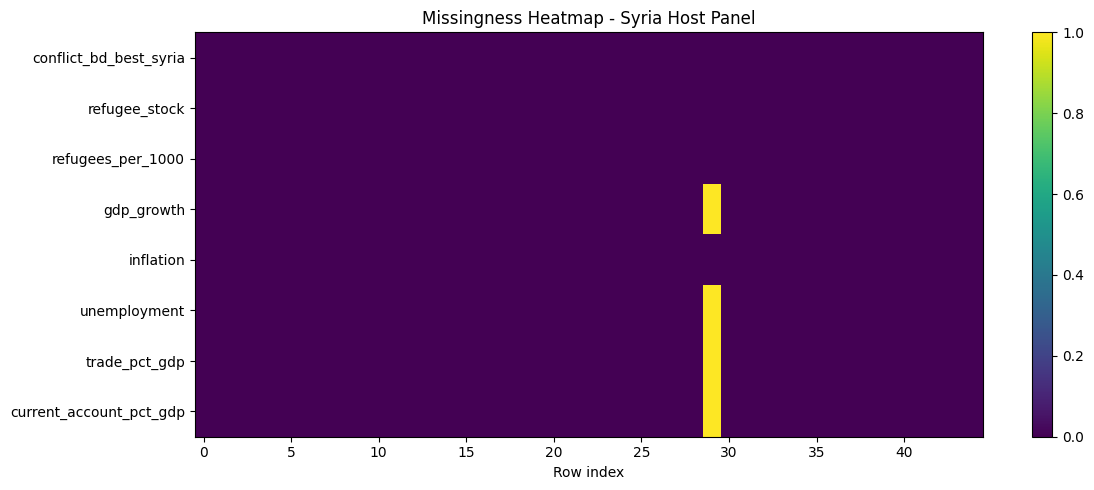

../outputs/figures/syria_missingness_heatmap.png


In [5]:
plot_vars = [
    "conflict_bd_best_syria",
    "refugee_stock",
    "refugees_per_1000",
    "gdp_growth",
    "inflation",
    "unemployment",
    "trade_pct_gdp",
    "current_account_pct_gdp",
]

missing_matrix = df[plot_vars].isna().astype(int).T

plt.figure(figsize=(12, 5))
plt.imshow(missing_matrix, aspect="auto")
plt.yticks(range(len(plot_vars)), plot_vars)
plt.xlabel("Row index")
plt.title("Missingness Heatmap - Syria Host Panel")
plt.colorbar()

missing_heatmap_path = FIG_DIR / "syria_missingness_heatmap.png"
plt.tight_layout()
plt.savefig(missing_heatmap_path, dpi=200, bbox_inches="tight")
plt.show()

print(missing_heatmap_path)

## Exploratory Data Analysis

This section visualizes:

- annual conflict intensity in Syria
- refugee burden across host countries
- host-country macroeconomic indicators over time
- bivariate relationships between refugee burden and selected outcomes

The goal is to understand the shape, scale, and variation of the data before interpreting test results.

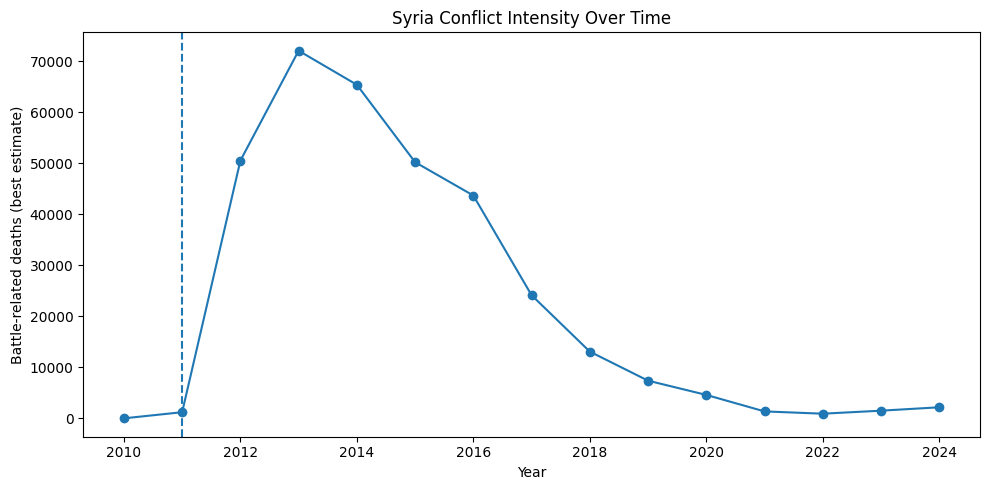

../outputs/figures/syria_conflict_intensity.png


In [6]:
conflict_ts = (
    df[["year", "conflict_bd_best_syria"]]
    .drop_duplicates()
    .sort_values("year")
)

plt.figure(figsize=(10, 5))
plt.plot(conflict_ts["year"], conflict_ts["conflict_bd_best_syria"], marker="o")
plt.axvline(2011, linestyle="--")
plt.title("Syria Conflict Intensity Over Time")
plt.xlabel("Year")
plt.ylabel("Battle-related deaths (best estimate)")

path_conflict = FIG_DIR / "syria_conflict_intensity.png"
plt.tight_layout()
plt.savefig(path_conflict, dpi=200, bbox_inches="tight")
plt.show()

print(path_conflict)

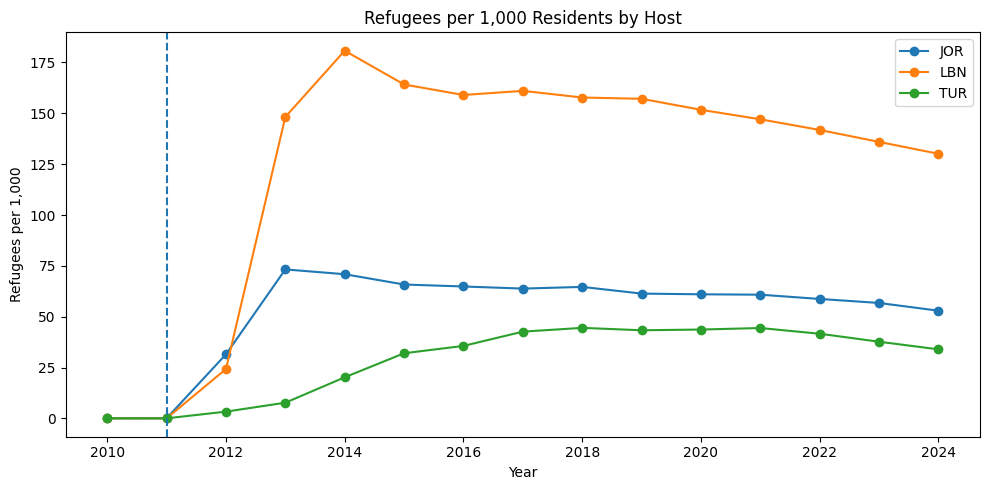

../outputs/figures/syria_refugees_per_1000_by_host.png


In [7]:
plt.figure(figsize=(10, 5))

for host in sorted(df["host_iso"].unique()):
    sub = df[df["host_iso"] == host].sort_values("year")
    plt.plot(sub["year"], sub["refugees_per_1000"], marker="o", label=host)

plt.axvline(2011, linestyle="--")
plt.title("Refugees per 1,000 Residents by Host")
plt.xlabel("Year")
plt.ylabel("Refugees per 1,000")
plt.legend()

path_refugee = FIG_DIR / "syria_refugees_per_1000_by_host.png"
plt.tight_layout()
plt.savefig(path_refugee, dpi=200, bbox_inches="tight")
plt.show()

print(path_refugee)

In [8]:
def plot_macro_by_host(data, y_col, title, out_name):
    plt.figure(figsize=(10, 5))

    for host in sorted(data["host_iso"].unique()):
        sub = data[data["host_iso"] == host].sort_values("year")
        plt.plot(sub["year"], sub[y_col], marker="o", label=host)

    plt.axvline(2011, linestyle="--")
    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel(y_col)
    plt.legend()

    out_path = FIG_DIR / out_name
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(out_path)

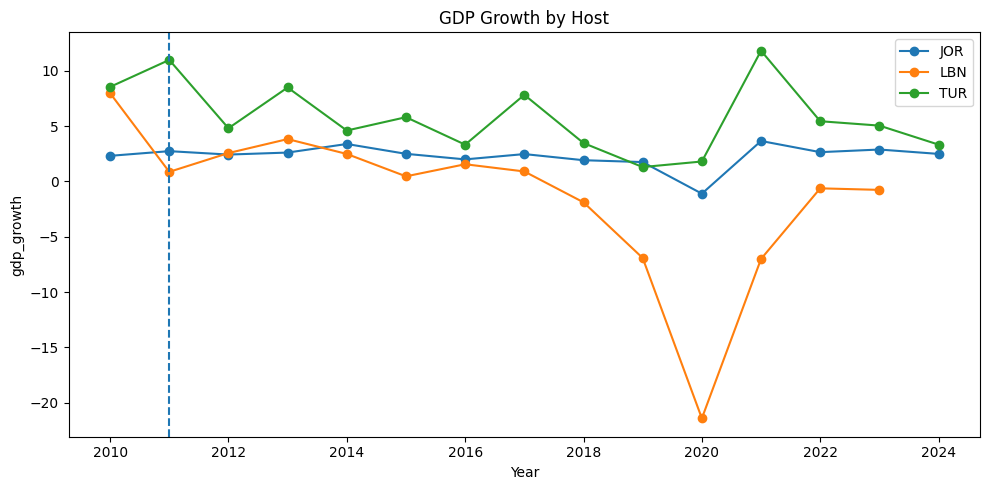

../outputs/figures/syria_gdp_growth_by_host.png


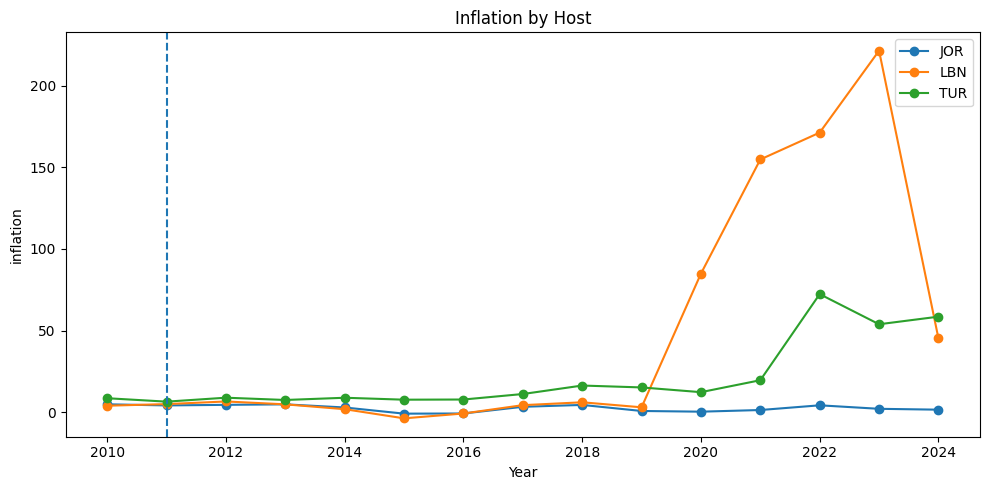

../outputs/figures/syria_inflation_by_host.png


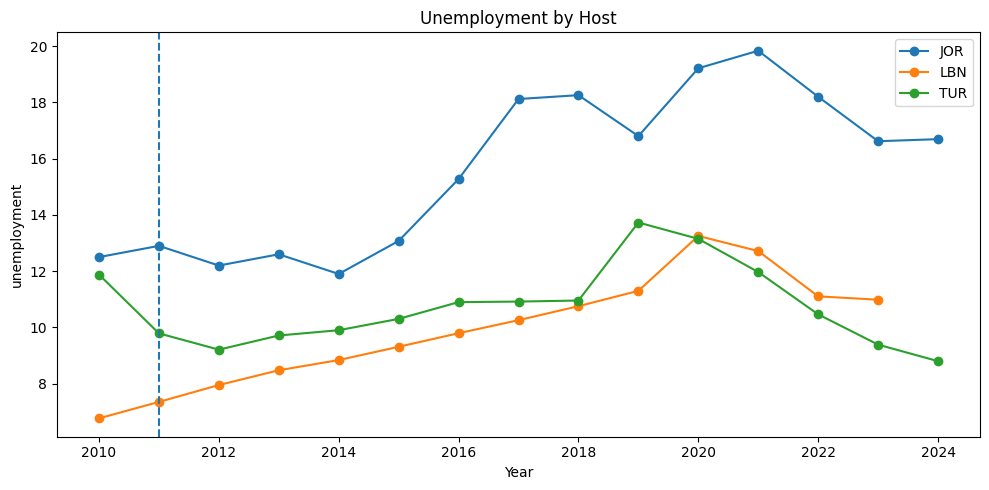

../outputs/figures/syria_unemployment_by_host.png


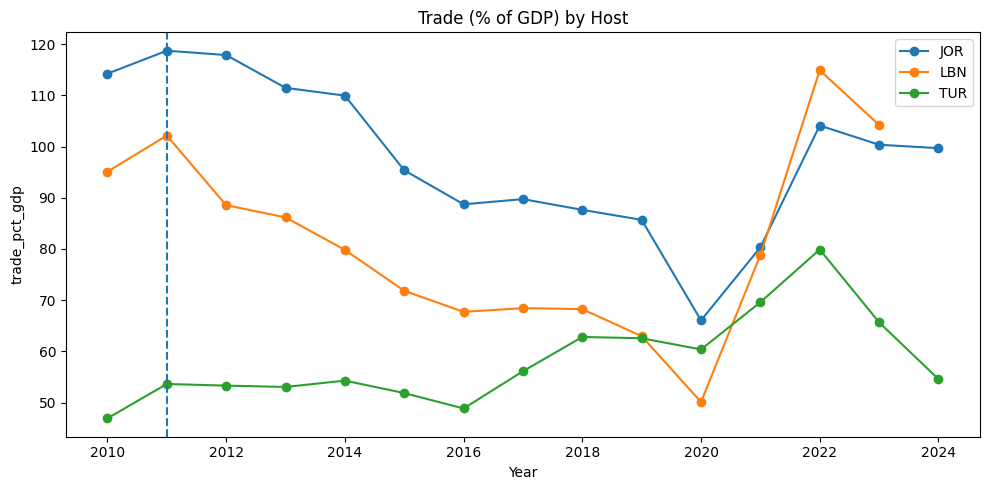

../outputs/figures/syria_trade_pct_gdp_by_host.png


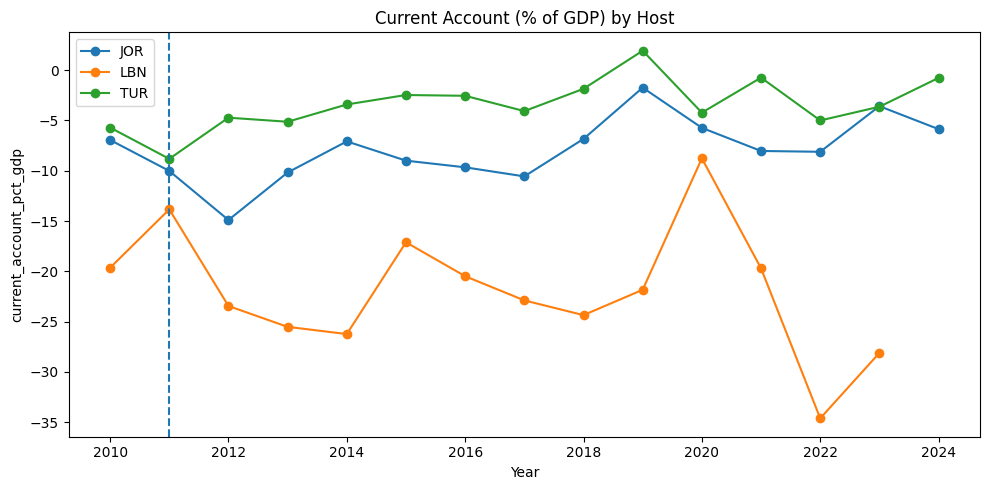

../outputs/figures/syria_current_account_by_host.png


In [9]:
plot_macro_by_host(df, "gdp_growth", "GDP Growth by Host", "syria_gdp_growth_by_host.png")
plot_macro_by_host(df, "inflation", "Inflation by Host", "syria_inflation_by_host.png")
plot_macro_by_host(df, "unemployment", "Unemployment by Host", "syria_unemployment_by_host.png")
plot_macro_by_host(df, "trade_pct_gdp", "Trade (% of GDP) by Host", "syria_trade_pct_gdp_by_host.png")
plot_macro_by_host(df, "current_account_pct_gdp", "Current Account (% of GDP) by Host", "syria_current_account_by_host.png")

In [10]:
def scatter_exposure_vs_outcome(data, outcome_col, out_name):
    temp = data[["year", "host_iso", "refugees_per_1000", outcome_col]].dropna().copy()

    plt.figure(figsize=(7, 5))
    plt.scatter(temp["refugees_per_1000"], temp[outcome_col])

    for _, row in temp.iterrows():
        plt.text(row["refugees_per_1000"], row[outcome_col], f'{row["host_iso"]}-{int(row["year"])}', fontsize=7)

    plt.title(f"Refugee Burden vs {outcome_col}")
    plt.xlabel("Refugees per 1,000")
    plt.ylabel(outcome_col)

    out_path = FIG_DIR / out_name
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(out_path)

## Bivariate Association Plots

This section visualizes the relationship between refugee burden and selected macroeconomic outcomes.

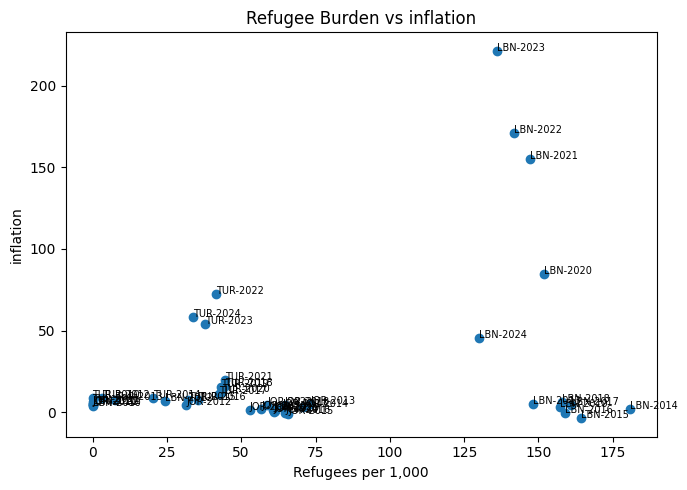

../outputs/figures/syria_scatter_refugees_vs_inflation.png


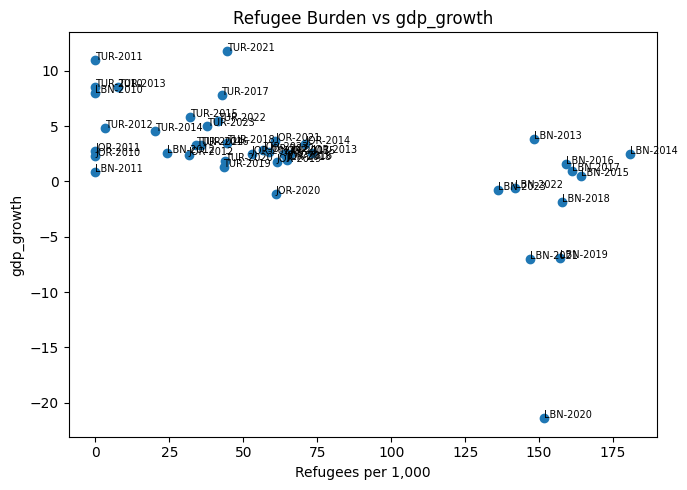

../outputs/figures/syria_scatter_refugees_vs_gdp_growth.png


In [11]:
scatter_exposure_vs_outcome(df, "inflation", "syria_scatter_refugees_vs_inflation.png")
scatter_exposure_vs_outcome(df, "gdp_growth", "syria_scatter_refugees_vs_gdp_growth.png")

## Hypotheses and Statistical Tests

The following preliminary hypotheses are evaluated:

### H1
Higher refugee burden is associated with lower GDP growth in host countries.

### H2
Higher refugee burden is associated with inflation in host countries.

## Methods

Two types of tests are used:

1. **Spearman correlation**
   - used to test monotonic association between `refugees_per_1000` and each macroeconomic outcome

2. **Mann–Whitney U test**
   - used after splitting observations into low- and high-refugee-burden groups based on the median of `refugees_per_1000`

These tests are exploratory and do not establish causality.

In [12]:
test_results = []

def add_spearman_test(data, x_col, y_col):
    temp = data[[x_col, y_col]].dropna().copy()
    n = len(temp)

    if n < 3:
        test_results.append({
            "test": "spearman",
            "x": x_col,
            "y": y_col,
            "n": n,
            "statistic": np.nan,
            "p_value": np.nan,
            "note": "not enough observations"
        })
        return

    stat, p = spearmanr(temp[x_col], temp[y_col])
    test_results.append({
        "test": "spearman",
        "x": x_col,
        "y": y_col,
        "n": n,
        "statistic": stat,
        "p_value": p,
        "note": ""
    })

def add_mannwhitney_test(data, burden_col, outcome_col):
    temp = data[[burden_col, outcome_col]].dropna().copy()
    n = len(temp)

    if n < 4:
        test_results.append({
            "test": "mannwhitney",
            "x": burden_col,
            "y": outcome_col,
            "n": n,
            "statistic": np.nan,
            "p_value": np.nan,
            "note": "not enough observations"
        })
        return

    cutoff = temp[burden_col].median()
    low_group = temp[temp[burden_col] <= cutoff][outcome_col]
    high_group = temp[temp[burden_col] > cutoff][outcome_col]

    if len(low_group) == 0 or len(high_group) == 0:
        test_results.append({
            "test": "mannwhitney",
            "x": burden_col,
            "y": outcome_col,
            "n": n,
            "statistic": np.nan,
            "p_value": np.nan,
            "note": "empty comparison group"
        })
        return

    stat, p = mannwhitneyu(low_group, high_group, alternative="two-sided")
    test_results.append({
        "test": "mannwhitney",
        "x": burden_col,
        "y": outcome_col,
        "n": n,
        "statistic": stat,
        "p_value": p,
        "note": f"median split at {cutoff:.4f}"
    })

add_spearman_test(df, "refugees_per_1000", "inflation")
add_spearman_test(df, "refugees_per_1000", "gdp_growth")
add_mannwhitney_test(df, "refugees_per_1000", "inflation")
add_mannwhitney_test(df, "refugees_per_1000", "gdp_growth")

test_results_df = pd.DataFrame(test_results)

test_results_path = TABLE_DIR / "syria_hypothesis_tests.csv"
test_results_df.to_csv(test_results_path, index=False)

print(test_results_df)
print(test_results_path)

          test                  x           y   n   statistic   p_value  \
0     spearman  refugees_per_1000   inflation  45   -0.234519  0.120986   
1     spearman  refugees_per_1000  gdp_growth  44   -0.620014  0.000007   
2  mannwhitney  refugees_per_1000   inflation  45  358.000000  0.017656   
3  mannwhitney  refugees_per_1000  gdp_growth  44  403.000000  0.000165   

                      note  
0                           
1                           
2  median split at 56.7426  
3  median split at 54.8354  
../outputs/tables/syria_hypothesis_tests.csv


## Interpretation of Preliminary Test Results

The test results suggest a statistically significant negative association between refugee burden and GDP growth in the Syria host-country panel.

The Spearman correlation does not show a statistically significant monotonic association between refugee burden and inflation.

However, the Mann–Whitney U test suggests that inflation distributions differ between low- and high-refugee-burden observations.

These findings should be interpreted as preliminary associations rather than causal effects.

In [13]:
summary_stats = df[[
    "conflict_bd_best_syria",
    "refugee_stock",
    "refugees_per_1000",
    "gdp_growth",
    "inflation",
    "unemployment",
    "trade_pct_gdp",
    "current_account_pct_gdp"
]].describe()

summary_stats_path = TABLE_DIR / "syria_summary_stats.csv"
summary_stats.to_csv(summary_stats_path)

print(summary_stats)
print(summary_stats_path)

       conflict_bd_best_syria  refugee_stock  refugees_per_1000  gdp_growth  \
count               45.000000   4.500000e+01          45.000000   44.000000   
mean             22532.266667   1.209811e+06          68.355869    2.347982   
std              25654.518567   1.192596e+06          56.078700    5.163816   
min                  0.000000   9.000000e+00           0.000123  -21.399900   
25%               1356.000000   6.114730e+05          32.007130    1.491318   
50%               7379.000000   7.554260e+05          56.742627    2.530660   
75%              50181.000000   1.147494e+06         130.112116    4.021104   
max              72016.000000   3.737369e+06         180.793415   11.811094   

        inflation  unemployment  trade_pct_gdp  current_account_pct_gdp  
count   45.000000     44.000000      44.000000                44.000000  
mean    23.580243     12.139250      79.151409               -10.813021  
std     47.668229      3.301317      21.828169                 8.9

## Notebook Output

This notebook saves the main outputs of the April 14 milestone under:

- `outputs/figures/`
- `outputs/tables/`

These outputs include:

- missingness summaries
- EDA figures
- hypothesis test results
- summary statistics